# Space Shoot

In [1]:
from rocketpy import Environment, Flight, Rocket, SolidMotor
import pandas as pd

In [2]:
%matplotlib inline

## Setting Up a Simulation


### Creating an Environment for Spaceport America

The `Environment` class is used to define the atmosphere, the winds, and the gravity models.

You can find more information about the `Environment` class in the [Environment Class Usage Docs](https://docs.rocketpy.org/en/latest/notebooks/environment/environment_class_usage.html).


In [3]:
env = Environment(latitude=40.8444, longitude=-119.1123, elevation=1127.76)

To get weather data from the GFS forecast, available online, we run the following lines.

First, we set tomorrow's date.


In [4]:
import datetime

#launch_date = datetime.datetime(year=2025, month=9, day=20)
launch_date = datetime.date.today()


env.set_date((launch_date.year, launch_date.month, launch_date.day, 12))  # Hour given in UTC time

Then, we tell env to use a GFS forecast to get the atmospheric conditions for flight.

Don't mind the warning, it just means that not all variables, such as wind speed or atmospheric temperature, are available at all altitudes given by the forecast.


In [5]:
env.set_atmospheric_model(type="Forecast", file="GFS")

We can see what the weather will look like by calling the info method!



Gravity Details

Acceleration of gravity at surface level:    9.7982 m/s²
Acceleration of gravity at   5.000 km (ASL): 9.7870 m/s²


Launch Site Details

Launch Date: 2025-05-12 12:00:00 UTC
Launch Site Latitude: 40.84440°
Launch Site Longitude: -119.11230°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 321929.30 W    4523631.48 N
Launch Site UTM zone: 11T
Launch Site Surface Elevation: 1362.4 m


Atmospheric Model Details

Atmospheric Model Type: Forecast
Forecast Maximum Height: 5.000 km
Forecast Time Period: from 2025-05-11 12:00:00 to 2025-05-27 12:00:00 utc
Forecast Hour Interval: 3 hrs
Forecast Latitude Range: From -90.0° to 90.0°
Forecast Longitude Range: From 0.0° to 359.75°

Surface Atmospheric Conditions

Surface Wind Speed: 6.35 m/s
Surface Wind Direction: 257.10°
Surface Wind Heading: 77.10°
Surface Pressure: 854.63 hPa
Surface Temperature: 281.18 K
Surface Air Density: 1.059 kg/m³
Surface Speed of Sound: 336.15 m/s


Earth Model Details

Earth Radius at Launch s

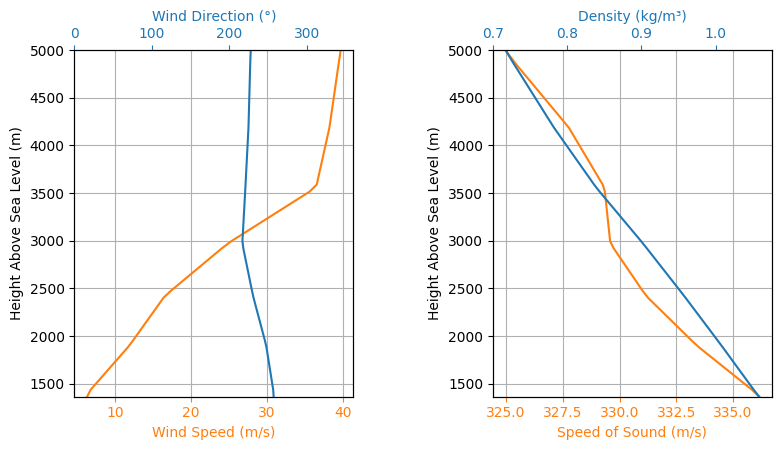

In [6]:
env.max_expected_height = 5000  # adjust the plots to this height
env.info()

### Creating a Motor

A solid rocket motor is used in this case. To create a motor, the SolidMotor class is used and the required arguments are given.

The SolidMotor class requires the user to have a thrust curve ready. This can come either from a .eng file for a commercial motor, such as below, or a .csv file from a static test measurement.

Besides the thrust curve, other parameters such as grain properties and nozzle dimensions must also be given.

See [Solid Motor Class Usage Docs](https://docs.rocketpy.org/en/latest/user/motors/solidmotor.html) for more information.


Nozzle Details
Nozzle Radius: 0.049149 m
Nozzle Throat Radius: 0.015 m

Grain Details
Number of Grains: 6
Grain Spacing: 0.005 m
Grain Density: 1743 kg/m3
Grain Outer Radius: 0.0428752 m
Grain Inner Radius: 0.018542 m
Grain Height: 0.1905 m
Grain Volume: 0.001 m3
Grain Mass: 1.559 kg

Motor Details
Total Burning Time: 3.819 s
Total Propellant Mass: 9.354 kg
Structural Mass Ratio: 0.374
Average Propellant Exhaust Velocity: 2046.013 m/s
Average Thrust: 5011.196 N
Maximum Thrust: 6652.99 N at 0.09 s after ignition.
Total Impulse: 19137.759 Ns



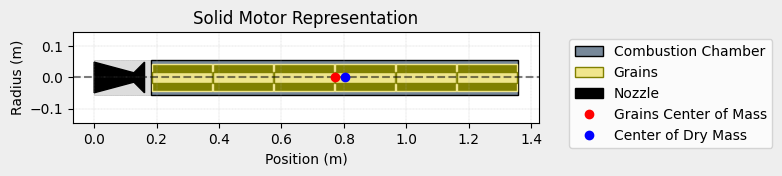

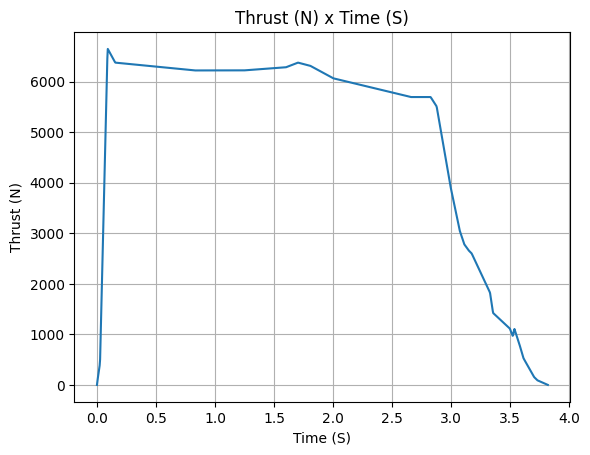

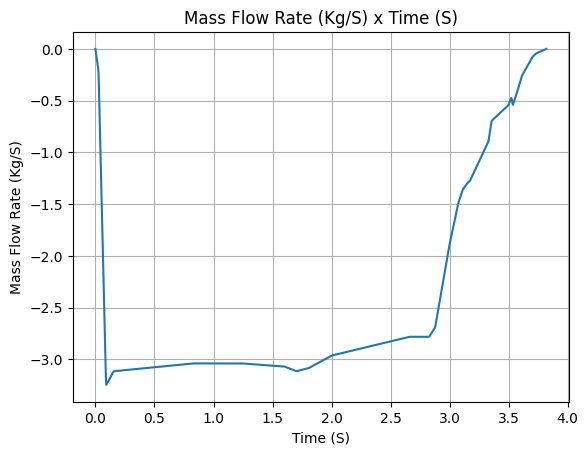

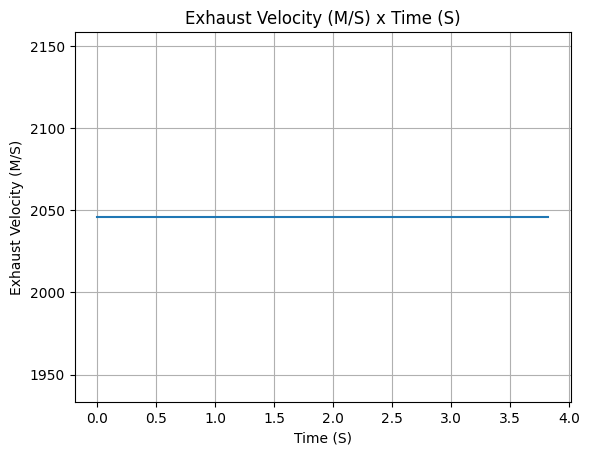

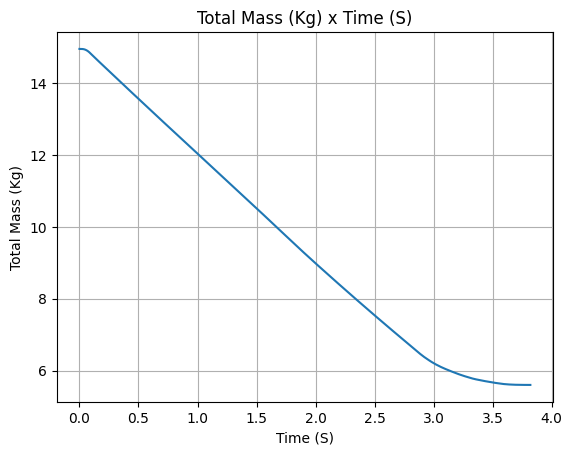

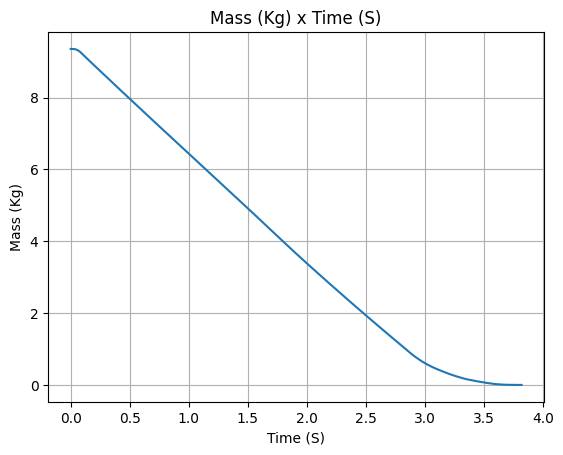

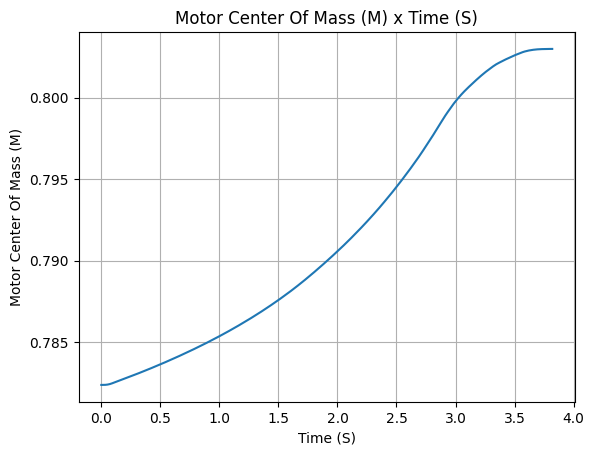

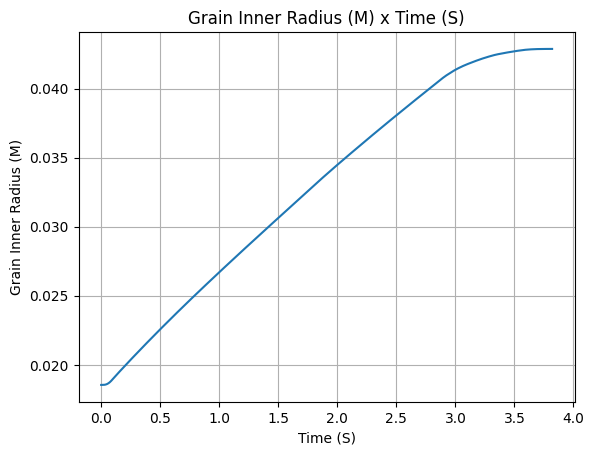

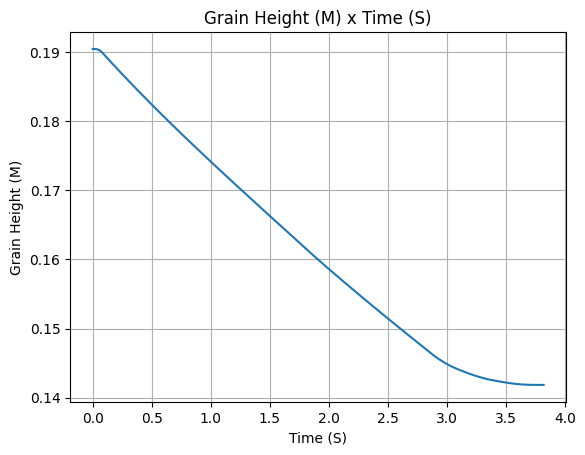

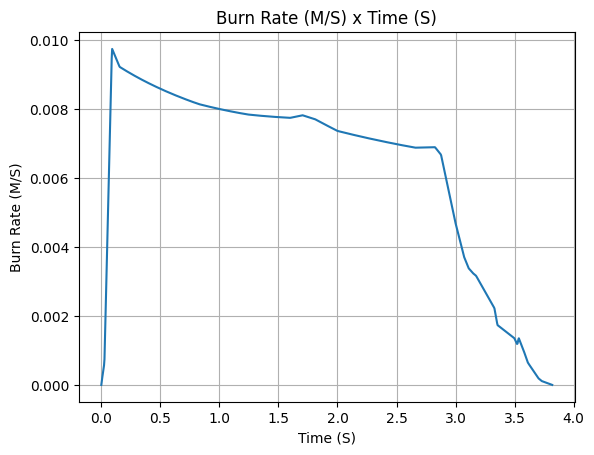

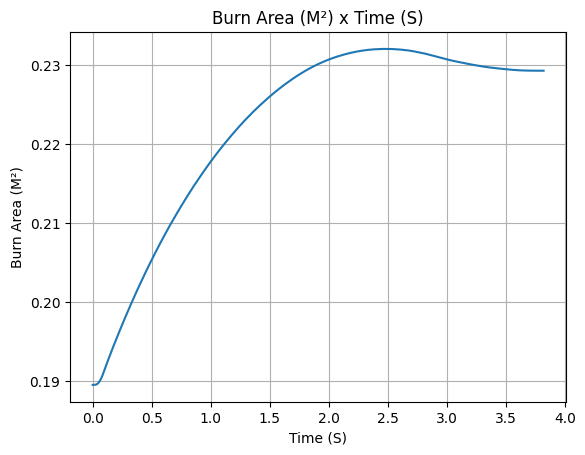

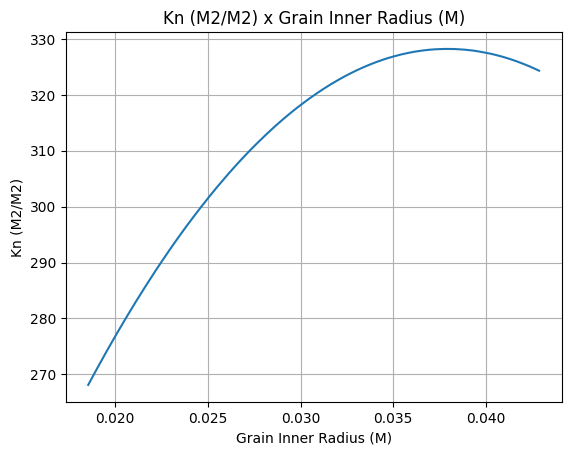

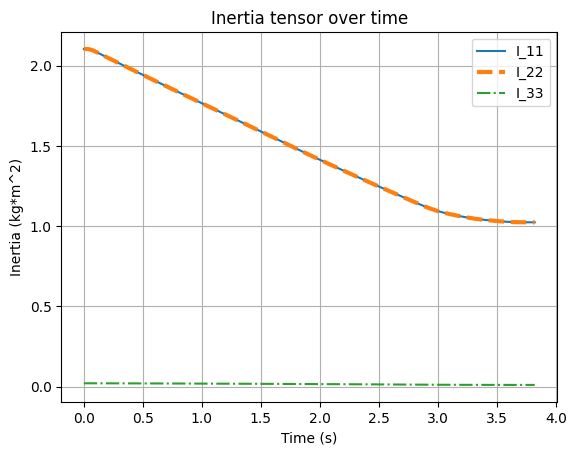

In [7]:
# IMPORTANT: modify the file path below to match your own system

# https://www.thrustcurve.org/motors/Loki/N5500LW/
# Booster first stage
ProN5500 = SolidMotor(
    thrust_source="files/n5500.eng",
    dry_mass= 5.599,
    dry_inertia=(1.024, 1.024, 0.011),
    nozzle_radius=0.049149,
    grain_number=6,
    grain_density=1743,
    grain_outer_radius= 0.0428752,
    grain_initial_inner_radius=0.018542,
    grain_initial_height=0.1905,
    grain_separation=5 / 1000,
    grains_center_of_mass_position=0.77,
    center_of_dry_mass_position=0.803,
    nozzle_position=0,
    burn_time=3.819,
    throat_radius=0.015,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

ProN5500.all_info()

Nozzle Details
Nozzle Radius: 0.026 m
Nozzle Throat Radius: 0.01 m

Grain Details
Number of Grains: 4
Grain Spacing: 0.005 m
Grain Density: 1743 kg/m3
Grain Outer Radius: 0.023 m
Grain Inner Radius: 0.009 m
Grain Height: 0.266 m
Grain Volume: 0.000 m3
Grain Mass: 0.653 kg

Motor Details
Total Burning Time: 4.079 s
Total Propellant Mass: 2.610 kg
Structural Mass Ratio: 0.246
Average Propellant Exhaust Velocity: 2054.392 m/s
Average Thrust: 1314.609 N
Maximum Thrust: 2318.606 N at 0.05 s after ignition.
Total Impulse: 5362.290 Ns



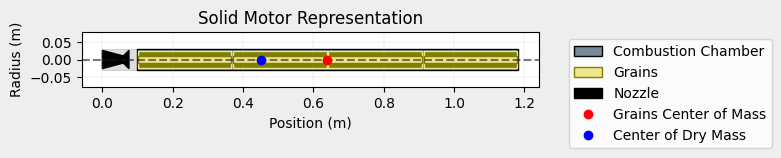

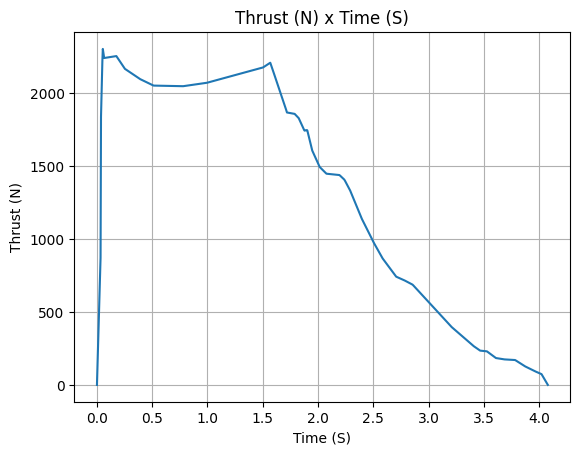

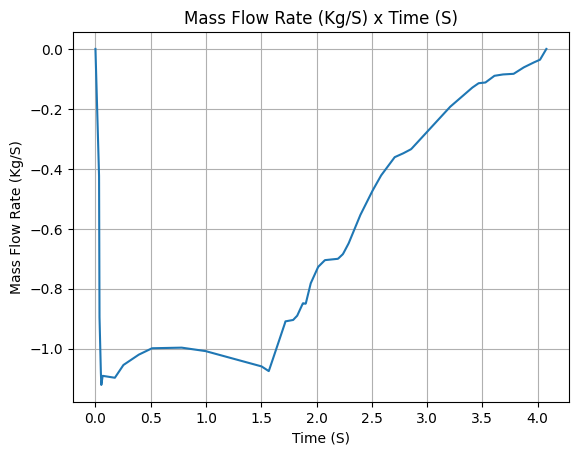

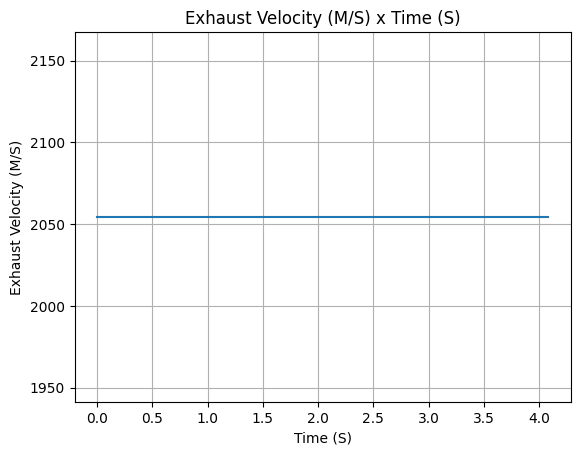

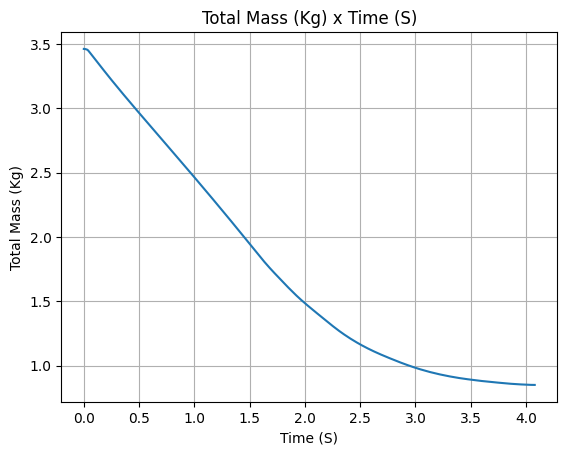

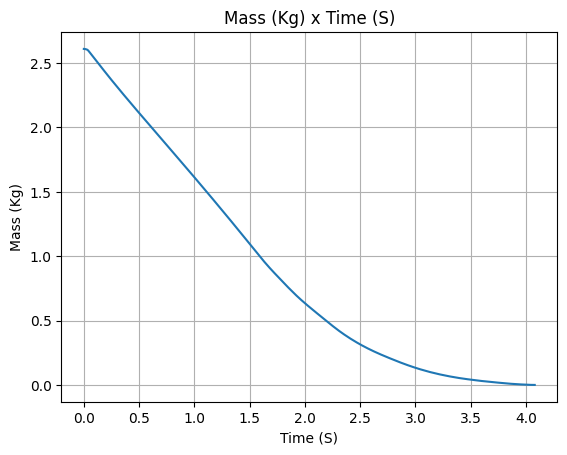

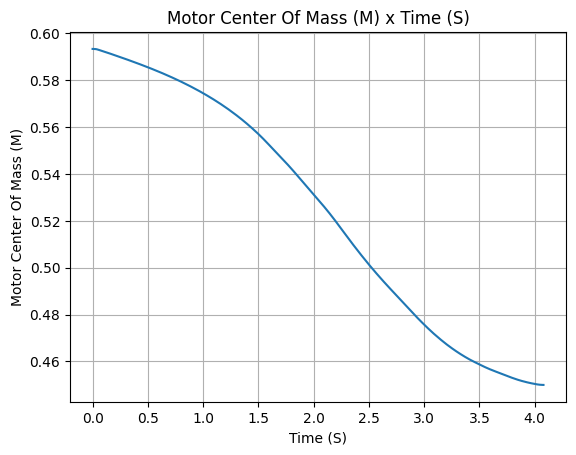

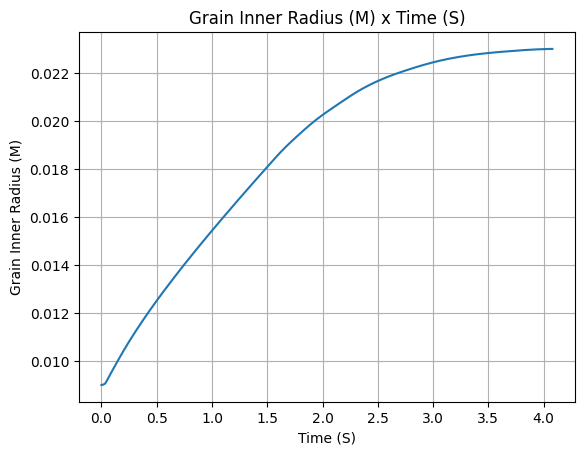

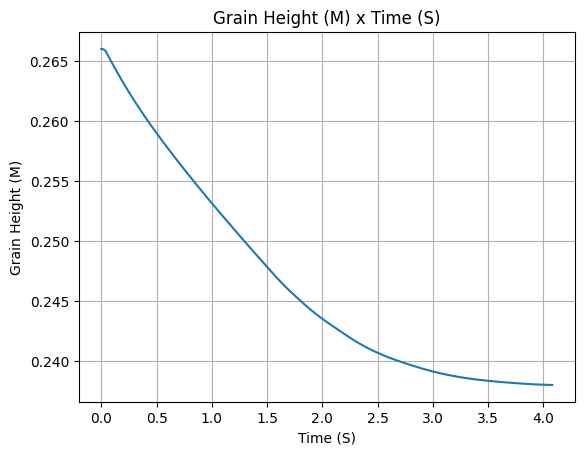

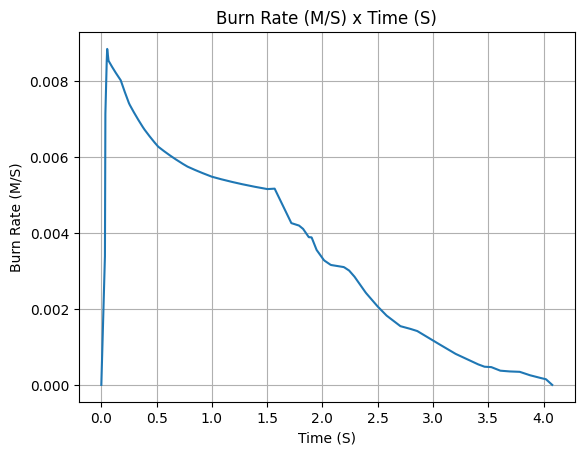

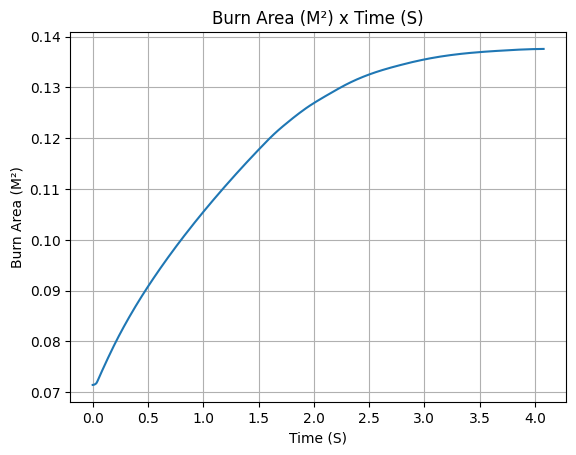

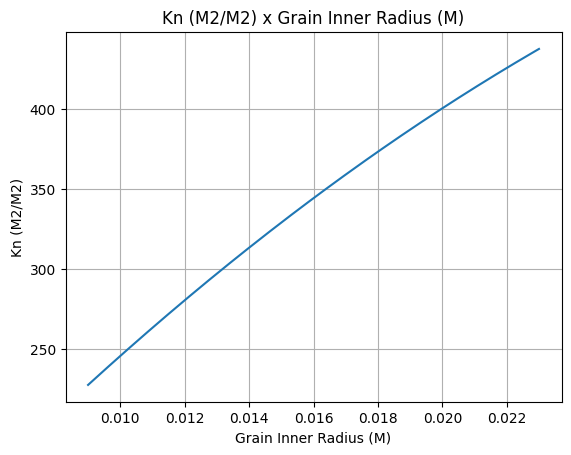

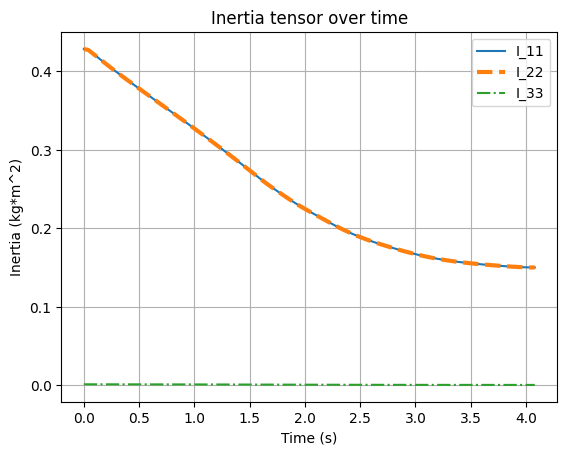

In [8]:
# Sustainer (second stage)
ProM1378 = SolidMotor(
    thrust_source="files/m1378.eng",
    dry_mass= 0.85,
    dry_inertia=(0.1501, 0.1501, 0.000469),
    nozzle_radius=0.026,
    grain_number=4,
    grain_density=1743, # different
    grain_outer_radius=0.023,
    grain_initial_inner_radius=0.009,
    grain_initial_height= 0.266,
    grain_separation=5/1000,
    grains_center_of_mass_position=0.64, # in relation to second stage nozzle
    center_of_dry_mass_position=0.45,
    nozzle_position=0,
    burn_time=4.079,
    throat_radius=0.01,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

ProM1378.all_info()

**Pay special attention to _position_ related parameters:**
More details on [Positions and Coordinate Systems](https://docs.rocketpy.org/en/latest/user/positions.html)


### Creating a Rocket


A rocket is composed of several components. Namely, we must have a motor (good thing we have the Pro75M1670 ready), a couple of aerodynamic surfaces (nose cone, fins and tail) and parachutes (if we are not launching a missile).

You can find more information about the `Rocket` class in the [Rocket Class Usage Docs](https://docs.rocketpy.org/en/latest/user/rocket.html).

Let's start by initializing our rocket, named Calisto, entering inertia properties, some dimensions and drag curves.

**Pay special attention to _position_ related parameters:**
More details on [Positions and Coordinate Systems](https://docs.rocketpy.org/en/latest/user/positions.html)



Inertia Details

Rocket Mass: 5.426 kg (without motor)
Rocket Dry Mass: 11.025 kg (with unloaded motor)
Rocket Loaded Mass: 20.379 kg
Rocket Structural Mass Ratio: 0.541
Rocket Inertia (with unloaded motor) 11: 25.260 kg*m2
Rocket Inertia (with unloaded motor) 22: 25.260 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.045 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.05461 m
Rocket Frontal Area: 0.009369 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 1.295 m
Rocket Center of Dry Mass - Nozzle Exit: 2.058 m
Rocket Center of Dry Mass - Center of Propellant Mass: 1.288 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.591 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 3.609/rad
Fins Lift Coefficient 

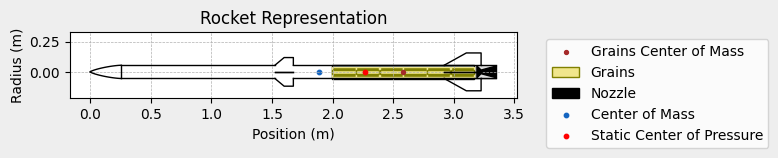


Mass Plots
----------------------------------------


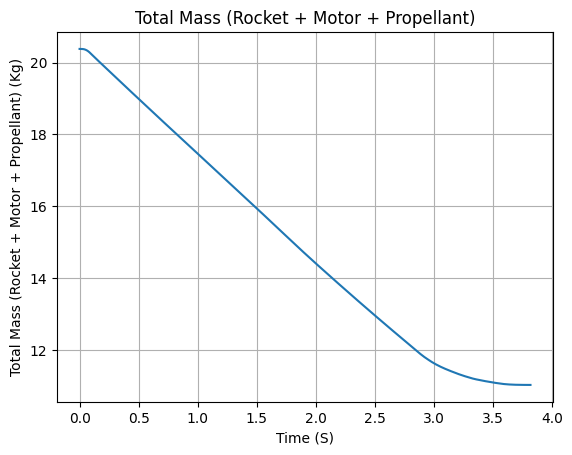

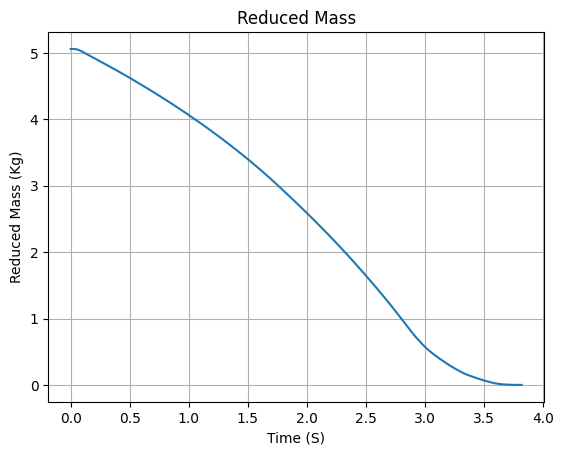


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


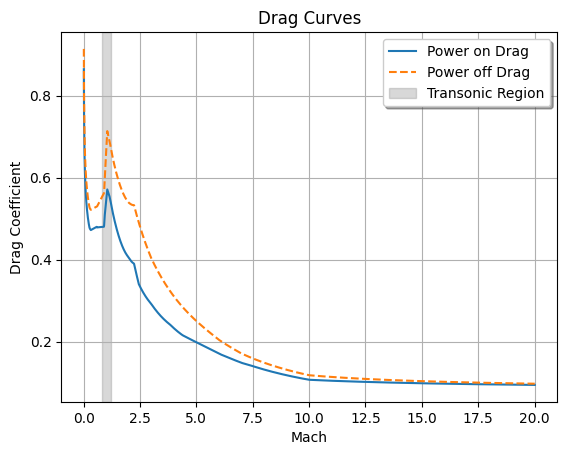


Stability Plots
--------------------


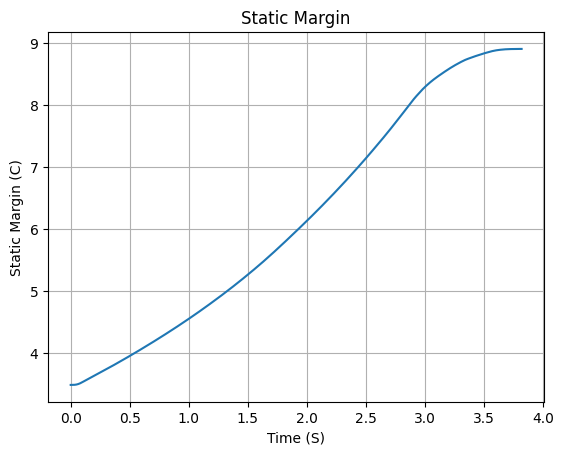

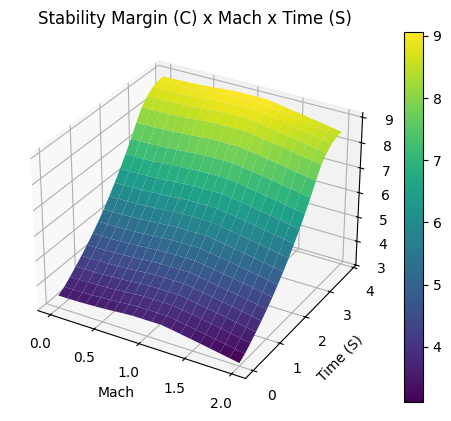


Thrust-to-Weight Plot
----------------------------------------


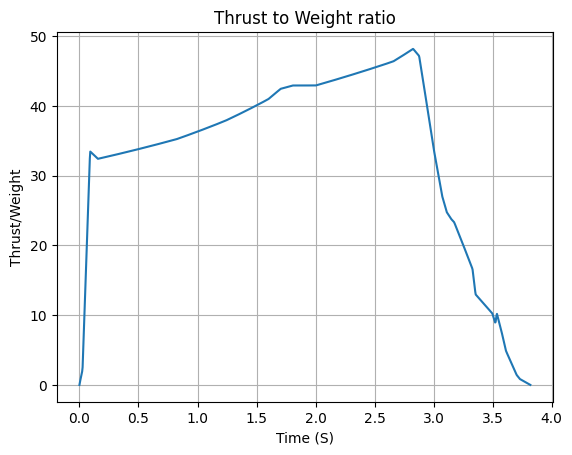

In [23]:
# IMPORTANT: modify the file paths below to match your own system

first_stage = Rocket(
    radius= 0.05461, # TODO how to deal with the radius? No transition possible (but should be account for in the drag file)
    mass= 5.426, # TODO
    inertia=(6.321, 6.321, 0.034), # TODO
    power_off_drag="files/first_stage_off.csv",
    power_on_drag="files/first_stage_on.csv",
    center_of_mass_without_motor=0,
    coordinate_system_orientation="nose_to_tail",
)

first_stage.add_motor(ProN5500, position=3.3528) # TODO position

# TODO no launch tower option
# rail_buttons = calisto.set_rail_buttons(
#     upper_button_position=0.0818,
#     lower_button_position=-0.618,
#     angular_position=45,
# )

nose_cone = first_stage.add_nose(length=0.254, kind="Von Karman", position=0) #TODO ogive is an option

# IMPORTANT: modify the file path below to match your own system
fins_upper = first_stage.add_trapezoidal_fins(
    n=4,
    root_chord=0.1524,
    tip_chord=0.0762,
    span=0.0635,
    position=1.524,
    cant_angle=0,
    #airfoil=("NACA0012-radians.txt", "radians"), # optional
)

fins_lower = first_stage.add_trapezoidal_fins(
    n=4,
    root_chord=0.3048,
    tip_chord=0.12192,
    span=0.1016,
    position=2.921,
    cant_angle=0,
    #airfoil=("NACA0012-radians.txt", "radians"), # optional
)

first_stage.all_info()


To see all information regarding the rocket we just defined we run:


#### Second Stage


Inertia Details

Rocket Mass: 1.000 kg (without motor)
Rocket Dry Mass: 1.850 kg (with unloaded motor)
Rocket Loaded Mass: 4.460 kg
Rocket Structural Mass Ratio: 0.415
Rocket Inertia (with unloaded motor) 11: 7.221 kg*m2
Rocket Inertia (with unloaded motor) 22: 7.221 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.034 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.05 m
Rocket Frontal Area: 0.007854 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.587 m
Rocket Center of Dry Mass - Nozzle Exit: 1.140 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.500 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.293 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 4.241/rad

Center of Pressure

Nose Con

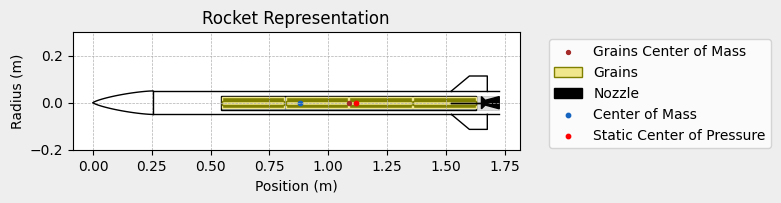


Mass Plots
----------------------------------------


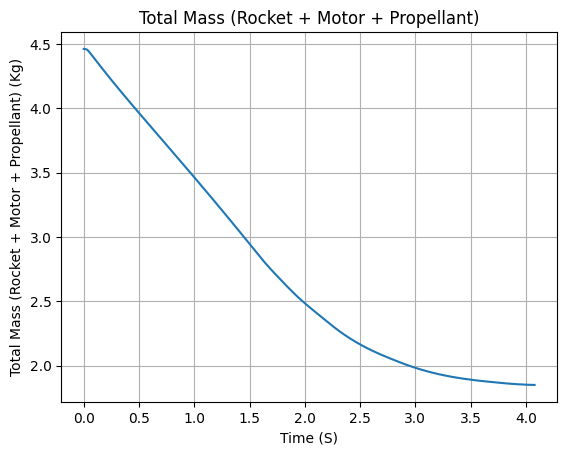

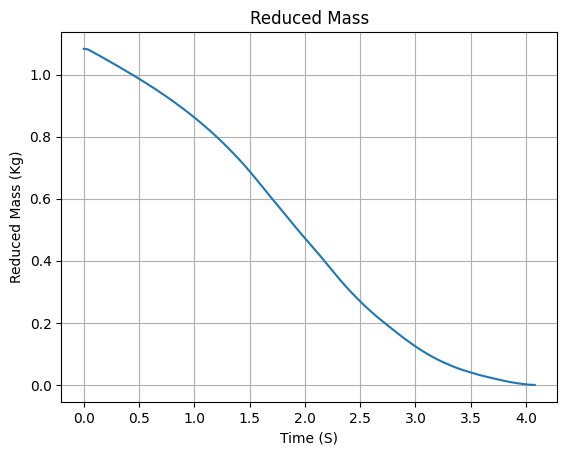


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


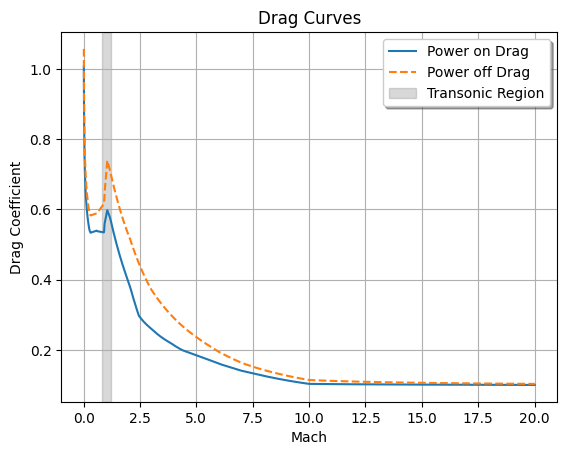


Stability Plots
--------------------


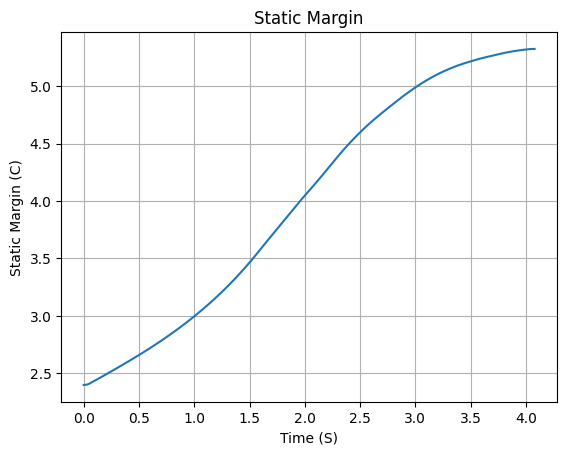

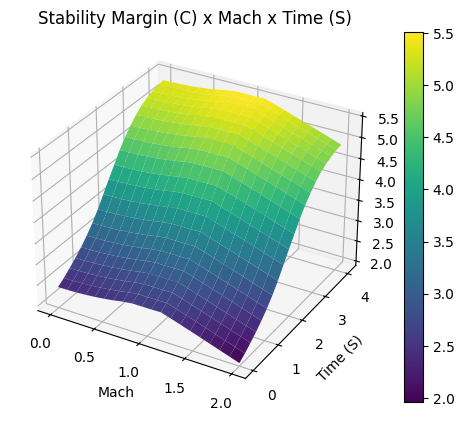


Thrust-to-Weight Plot
----------------------------------------


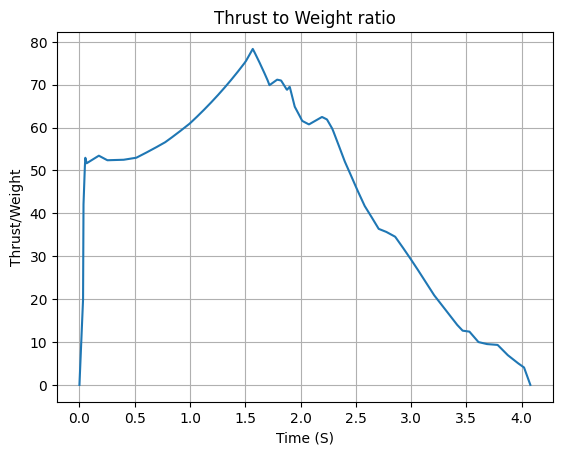

In [24]:
second_stage = Rocket(
    radius= 0.05, # TODO how to deal with the radius? No transition possible (but should be account for in the drag file)
    mass= 1.0, # TODO
    inertia=(6.321, 6.321, 0.034), # TODO
    power_off_drag="files/second_stage_off.csv",
    power_on_drag="files/second_stage_on.csv",
    center_of_mass_without_motor=0,
    coordinate_system_orientation="nose_to_tail",
)

second_stage.add_motor(ProM1378, position=1.7272) # TODO position

nose_cone = second_stage.add_nose(length=0.254, kind="Von Karman", position=0) #TODO ogive is an option

# IMPORTANT: modify the file path below to match your own system
fins_upper = second_stage.add_trapezoidal_fins(
    n=4,
    root_chord=0.1524,
    tip_chord=0.0762,
    span=0.0635,
    position=1.524,
    cant_angle=0,
    #airfoil=("NACA0012-radians.txt", "radians"), # optional
)

second_stage.all_info()

#### Adding Parachutes


Finally, we have parachutes! Calisto will have two parachutes, Drogue and Main. The Drogue parachute will open at apogee while the Main parachute will open at 800m above ground level

For more details see [Adding Parachutes](https://docs.rocketpy.org/en/latest/user/rocket.html#adding-parachutes)


In [25]:
# TODO 
# Main = calisto.add_parachute(
#     "Main",
#     cd_s=10.0,
#     trigger=800,
#     sampling_rate=105,
#     lag=1.5,
#     noise=(0, 8.3, 0.5),
# )

## Simulating a Flight

Simulating a flight trajectory is as simple as initializing a Flight class object givin the rocket and environnement set up above as inputs. The launch rail inclination and heading are also given here.


In [ ]:
first_stage_initial_flight = Flight(rocket=first_stage, environment=env, rail_length=1, inclination=80, heading=0)

tsecond_stage = 10

second_stage_flight = Flight(rocket=second_stage, environment=env,
    rail_length=0.1, # does not matter since the flight is starting at apogee
    inclination=first_stage_initial_flight.w1(tsecond_stage),
    heading=0,
    initial_solution=[0, first_stage_initial_flight.x(tsecond_stage), first_stage_initial_flight.y(tsecond_stage), first_stage_initial_flight.z(tsecond_stage), first_stage_initial_flight.vx(tsecond_stage), first_stage_initial_flight.vy(tsecond_stage), first_stage_initial_flight.vz(tsecond_stage), first_stage_initial_flight.e0(tsecond_stage), first_stage_initial_flight.e1(tsecond_stage), first_stage_initial_flight.e2(tsecond_stage), first_stage_initial_flight.e3(tsecond_stage), first_stage_initial_flight.w1(tsecond_stage), first_stage_initial_flight.w2(tsecond_stage), first_stage_initial_flight.w3(tsecond_stage)])

## Analyzing the Results

RocketPy gives you many plots, thats for sure! They are divided into sections to keep them organized. Alternatively, see the Flight class documentation to see how to get plots for specific variables only, instead of all of them at once.


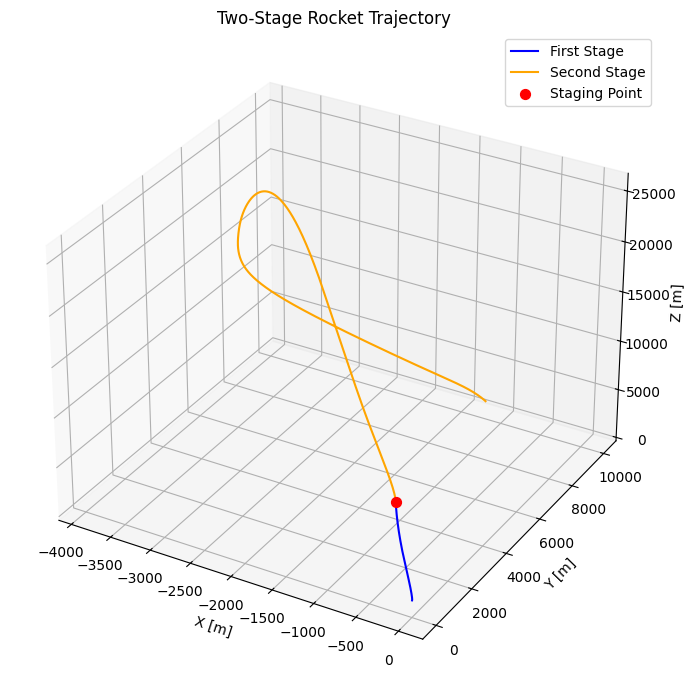

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Time arrays
t_staging = second_stage_flight.t
t_first_stage = np.linspace(0, tsecond_stage, 500)
t_second_stage = np.linspace(0, t_staging, 500)  # arbitrary duration for second stage

# Position data
x1 = first_stage_initial_flight.x(t_first_stage)
y1 = first_stage_initial_flight.y(t_first_stage)
z1 = first_stage_initial_flight.z(t_first_stage)

x2 = second_stage_flight.x(t_second_stage)
y2 = second_stage_flight.y(t_second_stage)
z2 = second_stage_flight.z(t_second_stage)

# Plotting
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot first stage
ax.plot(x1, y1, z1, label='First Stage', color='blue')

# Plot second stage
ax.plot(x2, y2, z2, label='Second Stage', color='orange')

# Mark staging point
ax.scatter(x1[-1], y1[-1], z1[-1], color='red', s=50, label='Staging Point')

# Labels and legend
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_zlabel('Z [m]')
ax.set_title('Two-Stage Rocket Trajectory')
ax.legend()
plt.tight_layout()
plt.show()




Trajectory 3d Plot



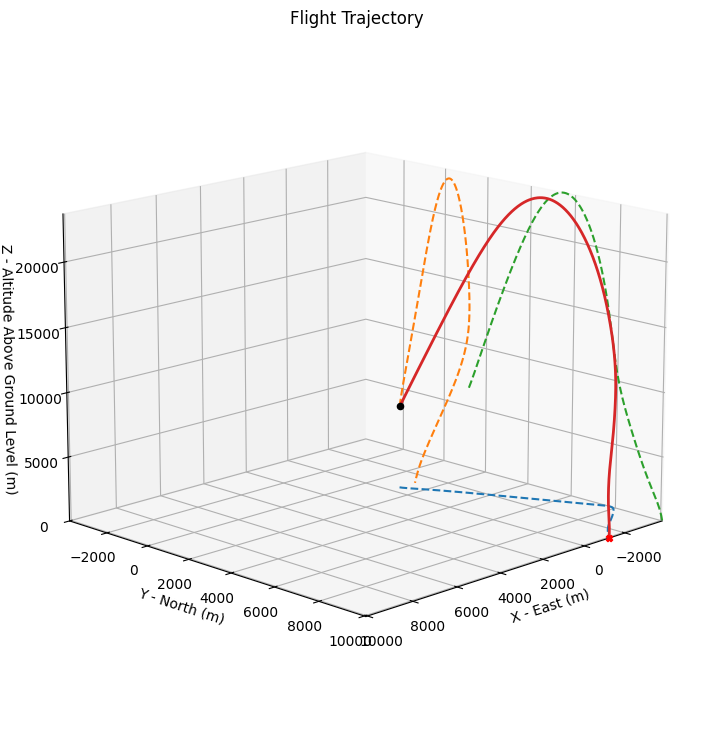



Trajectory Kinematic Plots



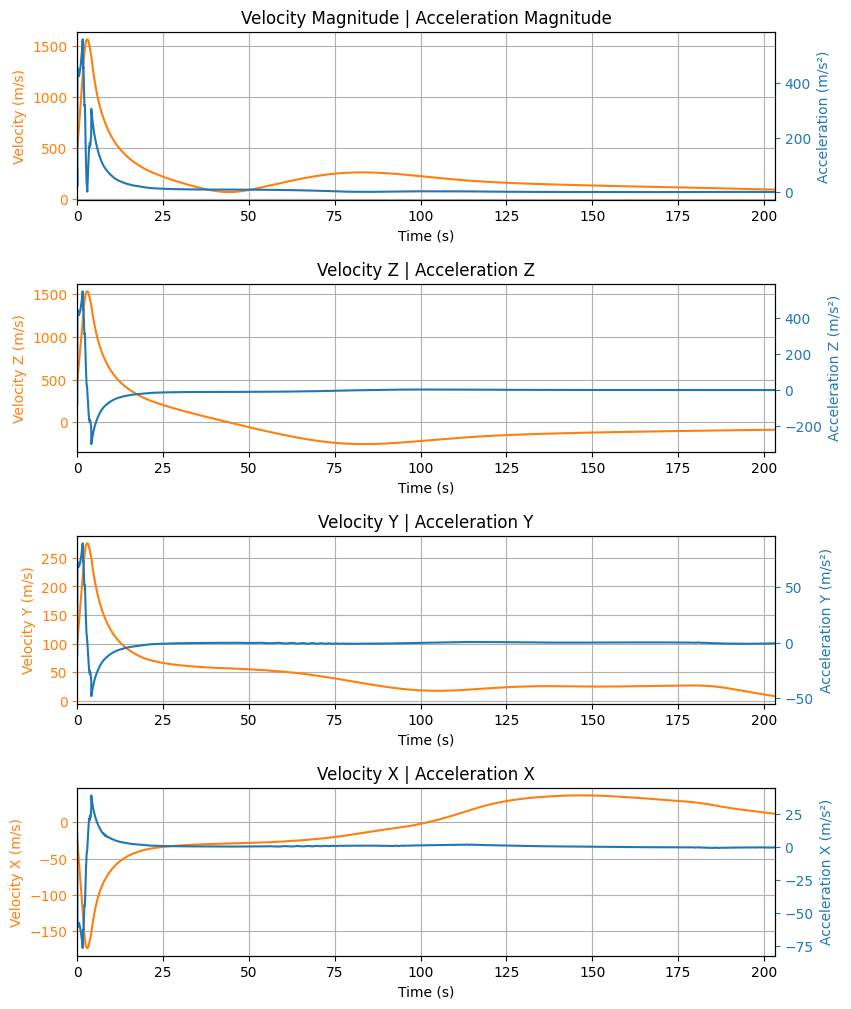



Angular Position Plots



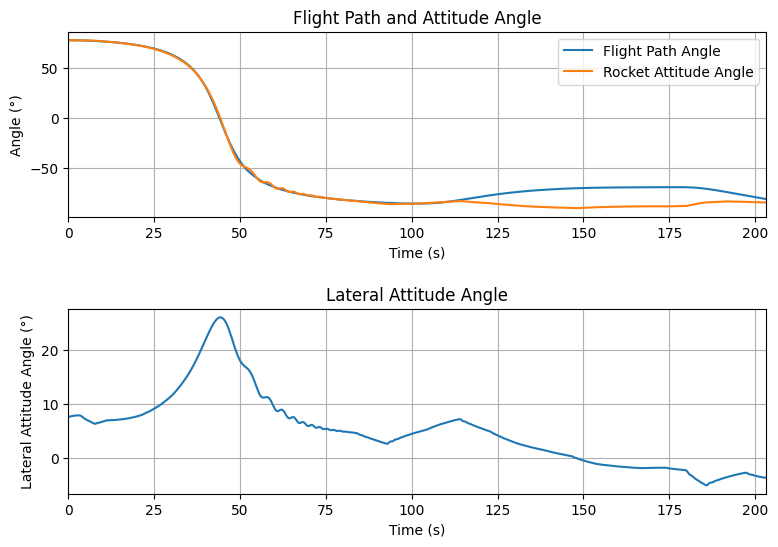



Path, Attitude and Lateral Attitude Angle plots



/home/stefan/Projects/rocketpy_test/.venv/lib/python3.12/site-packages/rocketpy/tools.py:1102: RuntimeWarning: invalid value encountered in arcsin
  return (180 / np.pi) * 2 * np.arcsin(-((e1**2 + e2**2) ** 0.5))


ValueError: array must not contain infs or NaNs

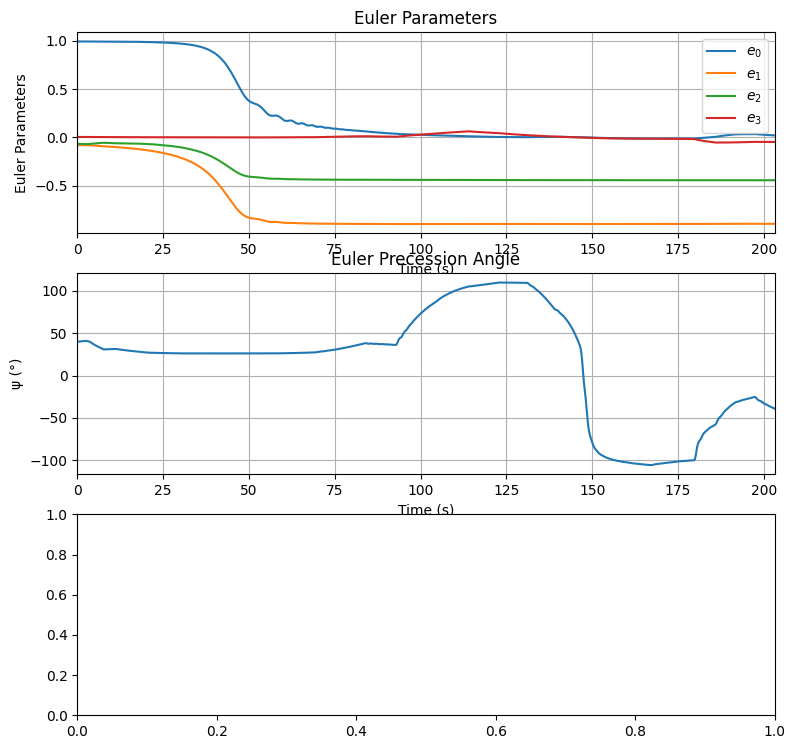

In [28]:
second_stage_flight.plots.all()

Export Flight Trajectory to a .kml file so it can be opened on Google Earth


In [152]:
test_flight.export_kml(
    file_name="trajectory.kml",
    extrude=True,
    altitude_mode="relative_to_ground",
)

File  trajectory.kml  saved with success!
